# March Madness 2025 Prediction Pipeline

This notebook orchestrates the complete end-to-end prediction process for the 2025 March Madness tournaments (both men's and women's). It uses the ELO-enhanced machine learning approach to generate predictions.

## Pipeline Steps
1. Load and preprocess data for both men's and women's tournaments
2. Calculate ELO ratings and advanced statistics
3. Train ELO-enhanced ML models for both tournaments
4. Generate predictions for all possible matchups
5. Identify and visualize predictions for actual tournament teams
6. Create consolidated submission file

## 1. Import Required Libraries and Configure Settings

In [1]:
# Enable auto-reloading of modules
%load_ext autoreload
%autoreload 2

# Standard libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set a nice plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

# Import our custom classes
from data_classes.processing import (
    MarchMadnessDataManager, 
    EloRatingSystem, 
    TeamStatsCalculator,
    MarchMadnessMLModel,
    MarchMadnessPredictor
)
from data_classes.bracket import BracketSimulator

In [3]:
# Configuration
CURRENT_SEASON = 2025                 # Target season
DATA_DIR = f"../data/{CURRENT_SEASON}"    # Directory for men's tournament data
ELO_START_YEAR = 2003                 # First year for ELO calculations
ML_START_YEAR = 2019                 # First year for ML training
SUBMISSION_FILE = "submission_2025.csv"  # Combined submission file

# Ensure output directory exists
os.makedirs("output", exist_ok=True)

## 2. Initialize Men's Tournament Components

In [4]:
# Initialize data manager for men's tournament
men_data_manager = MarchMadnessDataManager(DATA_DIR, "M", CURRENT_SEASON)

# Load all data files for men's tournament
men_data = men_data_manager.load_data()

# Display summary of loaded data
print("Loaded men's tournament data files:")
for key, df in men_data.items():
    print(f"  - {key}: {df.shape[0]} rows, {df.shape[1]} columns")

Loaded 10 datasets
Loaded men's tournament data files:
  - teams: 364 rows, 4 columns
  - regular_season: 192930 rows, 8 columns
  - tourney_results: 2518 rows, 8 columns
  - tourney_seeds: 2626 rows, 3 columns
  - tourney_slots: 2586 rows, 4 columns
  - regular_season_detailed: 118882 rows, 34 columns
  - tourney_detailed: 1382 rows, 34 columns
  - rankings: 5546091 rows, 5 columns
  - secondary_tourney: 1809 rows, 9 columns
  - processed_seeds: 2626 rows, 5 columns


In [10]:
# Initialize ELO rating system for men's tournament
men_elo_system = EloRatingSystem(men_data_manager)

# Calculate ELO ratings
print("Calculating ELO ratings for men's teams...")
men_elo_ratings = men_elo_system.calculate_elo_ratings(
    start_year=ELO_START_YEAR,
    k_factor=32,            # How much each game impacts ratings
    home_advantage=100,     # Home court advantage in ELO points
    carry_over_factor=0.6   # How much rating carries over between seasons
)

# Get current ELO ratings for the tournament teams
men_current_elo = men_elo_system.get_all_teams_elo(CURRENT_SEASON)

# Display top 10 men's teams by ELO rating
print("\nTop 10 men's teams by ELO rating:")
men_current_elo['TeamName'] = men_current_elo.index.map(lambda x: men_data_manager.get_team_name(x))
display(men_current_elo.sort_values('ELO', ascending=False).head(10))

Calculating ELO ratings for men's teams...
Calculating ELO ratings from 2003 to 2025...
Calculated ELO ratings for 23 seasons

Top 10 men's teams by ELO rating:


,TeamID,TeamName,ELO
113,1222,Team 113,1900.623951
74,1181,Team 74,1873.541620
89,1196,Team 89,1864.080176
17,1120,Team 17,1860.150967
283,1397,Team 283,1827.484278
3,1104,Team 3,1819.472936
271,1385,Team 271,1819.015111
72,1179,Team 72,1794.470731
168,1277,Team 168,1789.258761
163,1272,Team 163,1783.899162


In [11]:
# Initialize stats calculator for men's tournament
men_stats_calculator = TeamStatsCalculator(men_data_manager)

try:
    # Calculate advanced statistics
    print("Calculating advanced statistics for men's teams...")
    men_advanced_stats = men_stats_calculator.calculate_advanced_team_stats(start_season=ELO_START_YEAR)
    
    # Success message
    print(f"Calculated advanced statistics for {len(men_advanced_stats)} seasons")
except Exception as e:
    print(f"Error calculating advanced stats: {e}")

Calculating advanced statistics for men's teams...
Calculating advanced team stats from 2003 to 2025...
Calculated advanced stats for 23 seasons
Calculated advanced statistics for 23 seasons


Training ELO-enhanced ML model for men's tournament...
Training ELO-enhanced ML model...
Creating feature dataset...
Created feature dataset with 1868 samples
Training set: 1494 samples
Test set: 374 samples

Performance Comparison - ELO vs ELO-Enhanced ML:
Metric               ELO Train    ELO Test     Enhanced Train Enhanced Test Improvement 
--------------------------------------------------------------------------------
Accuracy             0.6700         0.7139         0.7356         0.7299         0.0160
Brier Score          0.2047         0.1949         0.1735         0.1738         0.0211
Log Loss             0.5939         0.5710         0.5155         0.5169         0.0542
MSE on Residuals     N/A          N/A          0.1736         0.1739


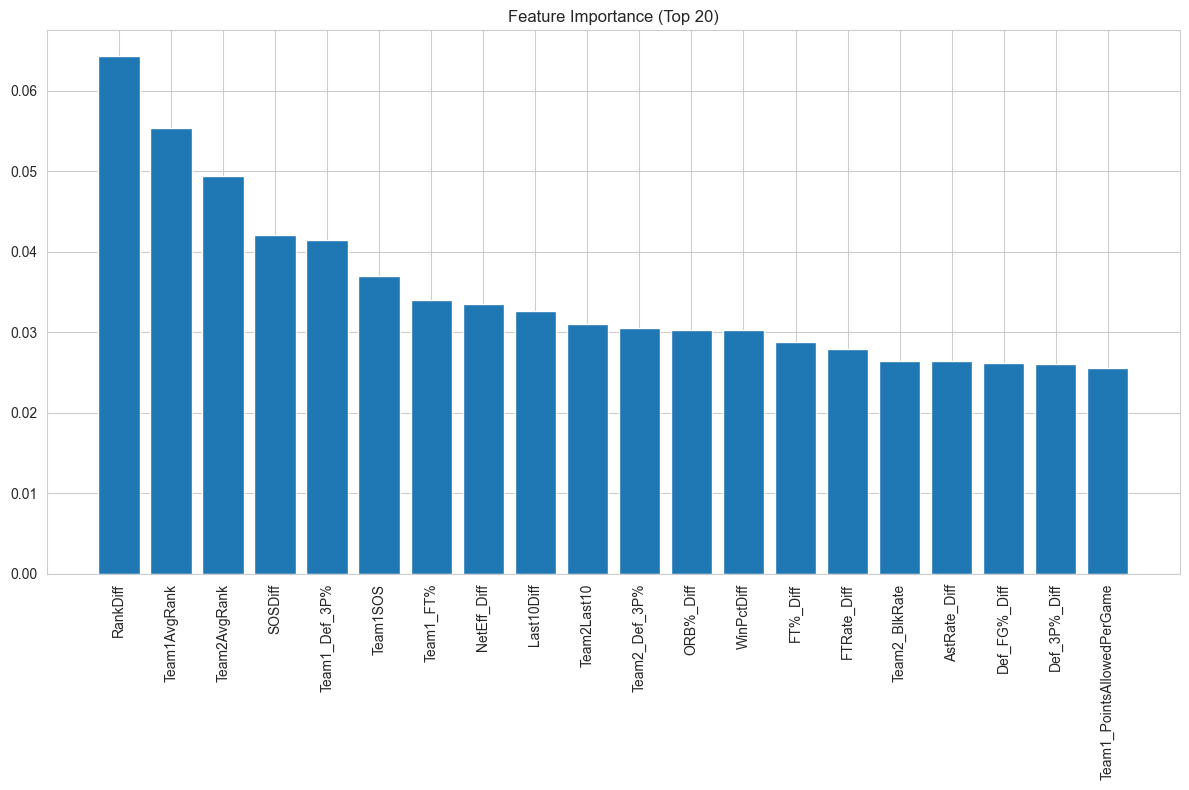

AttributeError: 'super' object has no attribute '__sklearn_tags__'

AttributeError: 'super' object has no attribute '__sklearn_tags__'

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.7, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.03, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=2, max_leaves=None,
             min_child_weight=3, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=50, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

In [12]:
# Initialize ML model for men's tournament
men_ml_model = MarchMadnessMLModel(
    men_data_manager,
    men_elo_system,
    men_stats_calculator
)
# Train ELO-enhanced ML model
print("Training ELO-enhanced ML model for men's tournament...")
men_ml_model.train_model(
    model_type='xgboost',
    test_size=0.2,
    random_state=42
)

In [13]:
# Initialize the predictor for men's tournament
men_predictor = MarchMadnessPredictor(
    data_manager=men_data_manager,
    elo_system=men_elo_system,
    stats_calculator=men_stats_calculator,
    ml_model=men_ml_model,
    current_season=CURRENT_SEASON
)

## 3. Initialize Women's Tournament Components

In [25]:
# Initialize data manager for women's tournament
women_data_manager = MarchMadnessDataManager(DATA_DIR, "W", CURRENT_SEASON)

# Load all data files for women's tournament
women_data = women_data_manager.load_data()

# Display summary of loaded data
print("Loaded women's tournament data files:")
for key, df in women_data.items():
    print(f"  - {key}: {df.shape[0]} rows, {df.shape[1]} columns")

Loaded 9 datasets
Loaded women's tournament data files:
  - teams: 362 rows, 2 columns
  - regular_season: 137028 rows, 8 columns
  - tourney_results: 1650 rows, 8 columns
  - tourney_seeds: 1744 rows, 3 columns
  - tourney_slots: 1780 rows, 4 columns
  - regular_season_detailed: 81708 rows, 34 columns
  - tourney_detailed: 894 rows, 34 columns
  - secondary_tourney: 828 rows, 9 columns
  - processed_seeds: 1744 rows, 5 columns


In [26]:
# Initialize ELO rating system for women's tournament
women_elo_system = EloRatingSystem(women_data_manager)

# Calculate ELO ratings
print("Calculating ELO ratings for women's teams...")
women_elo_ratings = women_elo_system.calculate_elo_ratings(
    start_year=ELO_START_YEAR,
    k_factor=30,            # How much each game impacts ratings
    home_advantage=100,     # Home court advantage in ELO points
    carry_over_factor=0.4   # How much rating carries over between seasons
)

# Get current ELO ratings for the tournament teams
women_current_elo = women_elo_system.get_all_teams_elo(CURRENT_SEASON)

# Display top 10 women's teams by ELO rating
print("\nTop 10 women's teams by ELO rating:")
women_current_elo['TeamName'] = women_current_elo.index.map(lambda x: women_data_manager.get_team_name(x))
display(women_current_elo.sort_values('ELO', ascending=False).head(10))

Calculating ELO ratings for women's teams...
Calculating ELO ratings from 2003 to 2025...
Calculated ELO ratings for 23 seasons

Top 10 women's teams by ELO rating:


,TeamID,TeamName,ELO
262,3376,Team 262,1875.120964
285,3400,Team 285,1858.769232
55,3163,Team 55,1857.597497
302,3417,Team 302,1855.630809
310,3425,Team 310,1831.331173
280,3395,Team 280,1796.298002
73,3181,Team 73,1781.112584
190,3301,Team 190,1777.233837
211,3323,Team 211,1772.810095
242,3355,Team 242,1771.910628


In [27]:
# Initialize stats calculator for women's tournament
women_stats_calculator = TeamStatsCalculator(women_data_manager)

try:
    # Calculate advanced statistics
    print("Calculating advanced statistics for women's teams...")
    women_advanced_stats = women_stats_calculator.calculate_advanced_team_stats(start_season=ELO_START_YEAR)
    
    # Success message
    print(f"Calculated advanced statistics for {len(women_advanced_stats)} seasons")
except Exception as e:
    print(f"Error calculating advanced stats: {e}")

Calculating advanced statistics for women's teams...
Calculating advanced team stats from 2003 to 2025...
Calculated advanced stats for 16 seasons
Calculated advanced statistics for 16 seasons


Training ELO-enhanced ML model for women's tournament...
Training ELO-enhanced ML model...
Creating feature dataset...
Created feature dataset with 1788 samples
Training set: 1430 samples
Test set: 358 samples

Performance Comparison - ELO vs ELO-Enhanced ML:
Metric               ELO Train    ELO Test     Enhanced Train Enhanced Test Improvement 
--------------------------------------------------------------------------------
Accuracy             0.6923         0.6816         0.8035         0.7514         0.0698
Brier Score          0.1911         0.1979         0.1437         0.1625         0.0355
Log Loss             0.5638         0.5773         0.4410         0.4817         0.0957
MSE on Residuals     N/A          N/A          0.1439         0.1626


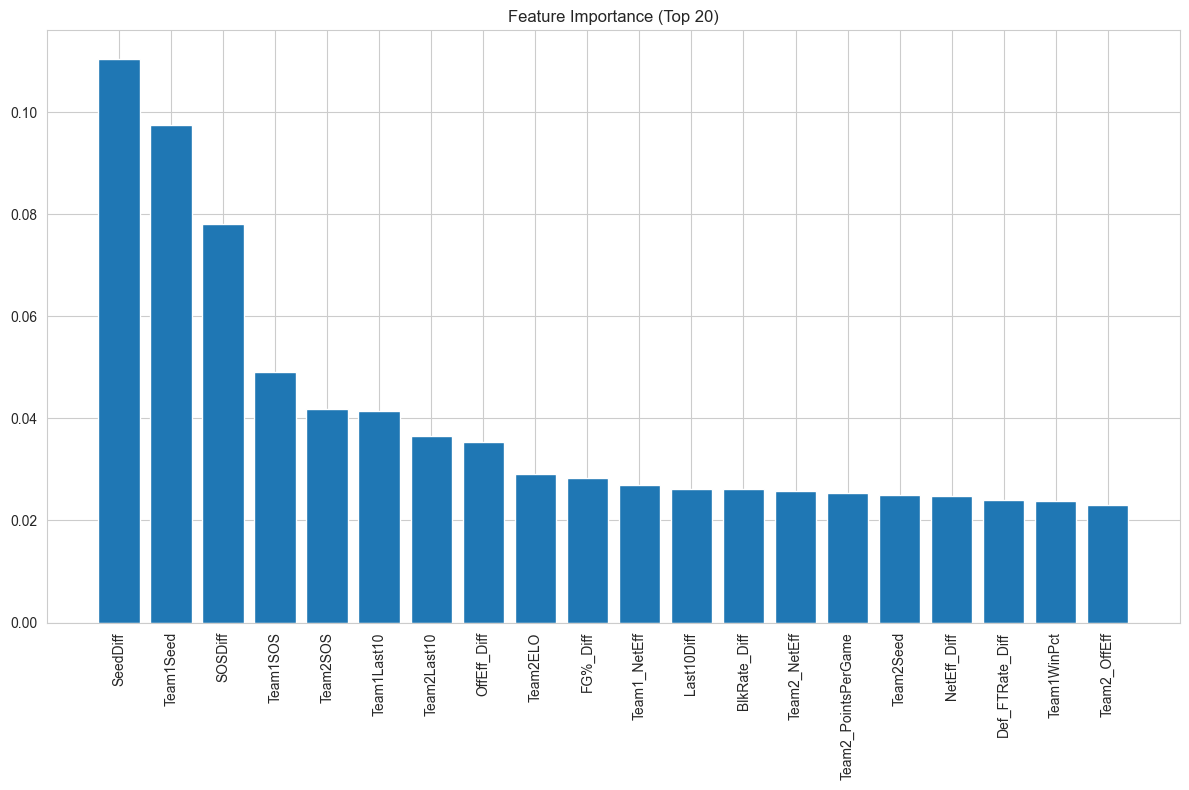

AttributeError: 'super' object has no attribute '__sklearn_tags__'

AttributeError: 'super' object has no attribute '__sklearn_tags__'

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.7, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.03, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=2, max_leaves=None,
             min_child_weight=3, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=50, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

In [28]:
# Initialize ML model for women's tournament
women_ml_model = MarchMadnessMLModel(
    women_data_manager,
    women_elo_system,
    women_stats_calculator
)

# Train ELO-enhanced ML model
print("Training ELO-enhanced ML model for women's tournament...")
women_ml_model.train_model(
    model_type='xgboost',
    test_size=0.2,
    random_state=42
)

In [29]:
# Initialize the predictor for women's tournament
women_predictor = MarchMadnessPredictor(
    data_manager=women_data_manager,
    elo_system=women_elo_system,
    stats_calculator=women_stats_calculator,
    ml_model=women_ml_model,
    current_season=CURRENT_SEASON
)

## 4. Evaluate Model Performance with Backtesting

Comparing prediction methods for men's tournament...
Backtesting elo predictions on 5 tournament seasons: [2019, 2021, 2022, 2023, 2024]
Backtesting on 2019 tournament using elo method...
Brier Score: 0.1748
Accuracy: 0.6866
Log Loss: 0.5118
Backtesting on 2021 tournament using elo method...
Brier Score: 0.2260
Accuracy: 0.6515
Log Loss: 0.6364
Backtesting on 2022 tournament using elo method...
Brier Score: 0.2260
Accuracy: 0.6567
Log Loss: 0.6428
Backtesting on 2023 tournament using elo method...
Brier Score: 0.2185
Accuracy: 0.6716
Log Loss: 0.6389
Backtesting on 2024 tournament using elo method...
Brier Score: 0.1942
Accuracy: 0.6716
Log Loss: 0.5628

Aggregate Results:
Seasons: 5
Average Brier Score: 0.2079
Average Accuracy: 0.6676
Average Log Loss: 0.5986
Backtesting elo_enhanced predictions on 5 tournament seasons: [2019, 2021, 2022, 2023, 2024]
Backtesting on 2019 tournament using elo_enhanced method...
Brier Score: 0.1631
Accuracy: 0.7015
Log Loss: 0.4657
Backtesting on 2021 to

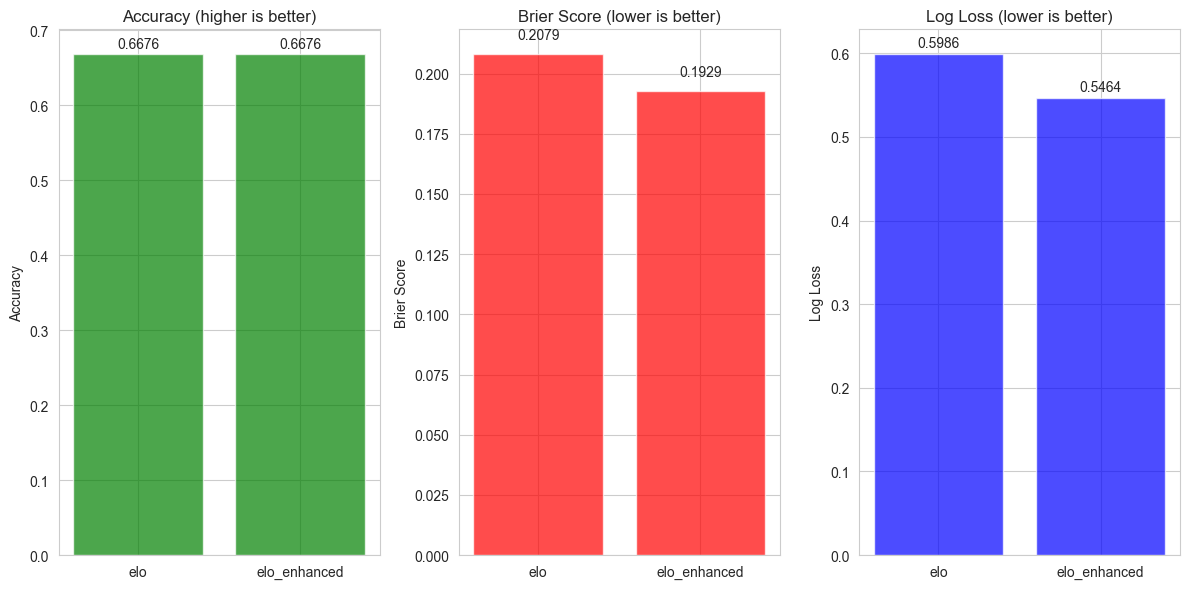


Best method for men's tournament based on backtesting: elo_enhanced


In [14]:
# Compare men's prediction methods on historical tournaments
print("Comparing prediction methods for men's tournament...")
men_comparison = men_predictor.compare_methods(visualize=True)

# Extract the best method for men's predictions
men_best_method = men_comparison.loc[men_comparison['Log Loss'].idxmin(), 'Method']
print(f"\nBest method for men's tournament based on backtesting: {men_best_method}")

Comparing prediction methods for women's tournament...
Backtesting elo predictions on 5 tournament seasons: [2019, 2021, 2022, 2023, 2024]
Backtesting on 2019 tournament using elo method...
Brier Score: 0.1525
Accuracy: 0.8254
Log Loss: 0.4699
Backtesting on 2021 tournament using elo method...
Brier Score: 0.1703
Accuracy: 0.7302
Log Loss: 0.5116
Backtesting on 2022 tournament using elo method...
Brier Score: 0.1674
Accuracy: 0.7612
Log Loss: 0.5102
Backtesting on 2023 tournament using elo method...
Brier Score: 0.1745
Accuracy: 0.7164
Log Loss: 0.5264
Backtesting on 2024 tournament using elo method...
Brier Score: 0.1562
Accuracy: 0.8060
Log Loss: 0.4835

Aggregate Results:
Seasons: 5
Average Brier Score: 0.1642
Average Accuracy: 0.7678
Average Log Loss: 0.5003
Backtesting elo_enhanced predictions on 5 tournament seasons: [2019, 2021, 2022, 2023, 2024]
Backtesting on 2019 tournament using elo_enhanced method...
Brier Score: 0.1235
Accuracy: 0.8095
Log Loss: 0.3751
Backtesting on 2021 

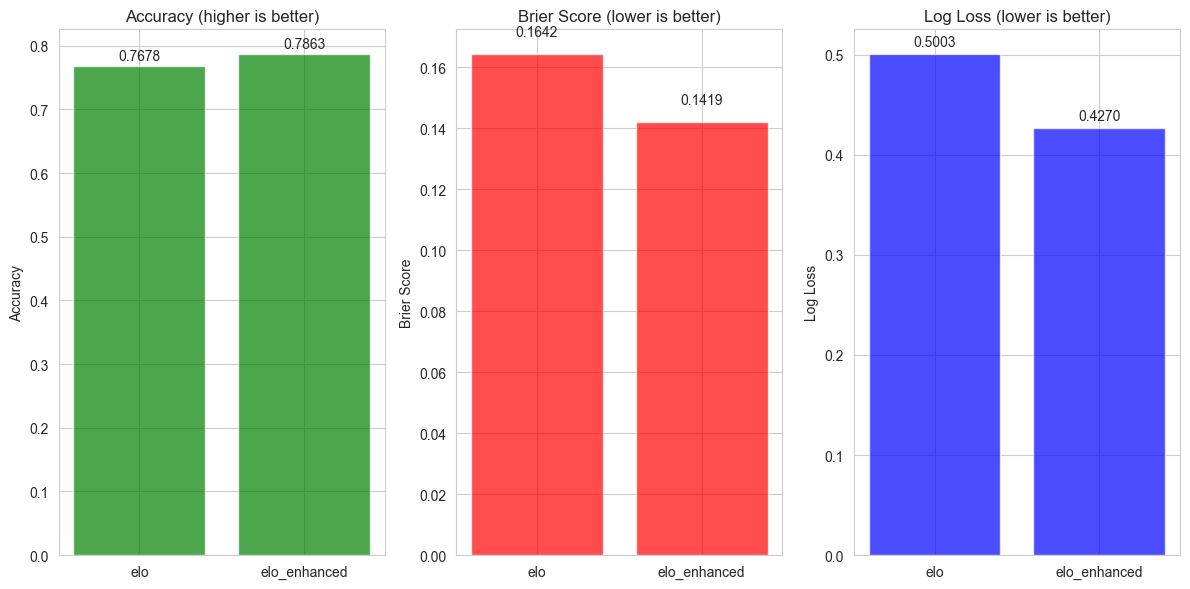


Best method for women's tournament based on backtesting: elo_enhanced


In [31]:
# Compare women's prediction methods on historical tournaments
print("Comparing prediction methods for women's tournament...")
women_comparison = women_predictor.compare_methods(visualize=True)

# Extract the best method for women's predictions
women_best_method = women_comparison.loc[women_comparison['Log Loss'].idxmin(), 'Method']
print(f"\nBest method for women's tournament based on backtesting: {women_best_method}")

## 5. Generate Predictions for Submission

In [15]:
# Generate men's tournament predictions using the best method
print(f"Generating men's tournament predictions using {men_best_method} method...")
men_predictions = men_predictor.generate_predictions(
    method=men_best_method,
    get_all_matchups=True,
    submission_file="submission_2025_M.csv"
)

print(f"Generated {len(men_predictions)} predictions for men's tournament")
display(men_predictions.head())

Generating men's tournament predictions using elo_enhanced method...
Generating predictions using elo_enhanced method...
new
Generating predictions for all 364 teams (66066 matchups)
Generating features for new matchup: 1101 vs 1102
Generating features for new matchup: 1101 vs 1103
Generating features for new matchup: 1101 vs 1104
Generating features for new matchup: 1101 vs 1105
Generating features for new matchup: 1101 vs 1106
Generating features for new matchup: 1101 vs 1107
Generating features for new matchup: 1101 vs 1108
Generating features for new matchup: 1101 vs 1110
Generating features for new matchup: 1101 vs 1111
Generating features for new matchup: 1101 vs 1112
Generating features for new matchup: 1101 vs 1113
Generating features for new matchup: 1101 vs 1114
Generating features for new matchup: 1101 vs 1115
Generating features for new matchup: 1101 vs 1116
Generating features for new matchup: 1101 vs 1117
Generating features for new matchup: 1101 vs 1119
Generating featur

,ID,Pred,Team1ID,Team2ID,Team1Name,Team2Name,Team1ELO,Team2ELO,Team1Seed,Team2Seed
0,2025_1101_1102,0.805881,1101,1102,Abilene Chr,Air Force,1470.987129,1253.908623,NaN,NaN
1,2025_1101_1103,0.181940,1101,1103,Abilene Chr,Akron,1470.987129,1700.952733,NaN,NaN
2,2025_1101_1104,0.035343,1101,1104,Abilene Chr,Alabama,1470.987129,1819.472936,NaN,NaN
3,2025_1101_1105,0.752271,1101,1105,Abilene Chr,Alabama A&M,1470.987129,1263.388136,NaN,NaN
4,2025_1101_1106,0.452944,1101,1106,Abilene Chr,Alabama St,1470.987129,1484.652089,NaN,NaN


In [16]:
men_predictions.to_csv('men.csv')

In [32]:
# Generate women's tournament predictions using the best method
print(f"Generating women's tournament predictions using {women_best_method} method...")
women_predictions = women_predictor.generate_predictions(
    method=women_best_method,
    get_all_matchups=True,
    submission_file="submission_2025_W.csv"
)

print(f"Generated {len(women_predictions)} predictions for women's tournament")
display(women_predictions.head())

Generating women's tournament predictions using elo_enhanced method...
Generating predictions using elo_enhanced method...
new
Generating predictions for all 362 teams (65341 matchups)
Processed 1000/65341 matchups (1.5%)
Processed 2000/65341 matchups (3.1%)
Processed 3000/65341 matchups (4.6%)
Processed 4000/65341 matchups (6.1%)
Processed 5000/65341 matchups (7.7%)
Processed 6000/65341 matchups (9.2%)
Processed 7000/65341 matchups (10.7%)
Processed 8000/65341 matchups (12.2%)
Processed 9000/65341 matchups (13.8%)
Processed 10000/65341 matchups (15.3%)
Processed 11000/65341 matchups (16.8%)
Processed 12000/65341 matchups (18.4%)
Processed 13000/65341 matchups (19.9%)
Processed 14000/65341 matchups (21.4%)
Processed 15000/65341 matchups (23.0%)
Processed 16000/65341 matchups (24.5%)
Processed 17000/65341 matchups (26.0%)
Processed 18000/65341 matchups (27.5%)
Processed 19000/65341 matchups (29.1%)
Processed 20000/65341 matchups (30.6%)
Processed 21000/65341 matchups (32.1%)
Processed 2

,ID,Pred,Team1ID,Team2ID,Team1Name,Team2Name,Team1ELO,Team2ELO,Team1Seed,Team2Seed
0,2025_3101_3102,0.507584,3101,3102,Abilene Chr,Air Force,1521.244501,1482.483934,NaN,NaN
1,2025_3101_3103,0.745395,3101,3103,Abilene Chr,Akron,1521.244501,1336.573709,NaN,NaN
2,2025_3101_3104,0.078683,3101,3104,Abilene Chr,Alabama,1521.244501,1677.364274,NaN,NaN
3,2025_3101_3105,0.541074,3101,3105,Abilene Chr,Alabama A&M,1521.244501,1548.125961,NaN,NaN
4,2025_3101_3106,0.828656,3101,3106,Abilene Chr,Alabama St,1521.244501,1260.510179,NaN,NaN


## 6. Create Combined Submission File

In [33]:
# Extract required columns for submission
men_submission = men_predictions[['ID', 'Pred']].copy()
women_submission = women_predictions[['ID', 'Pred']].copy()

# Combine men's and women's predictions
combined_submission = pd.concat([men_submission, women_submission])

# Drop any duplicates (should not happen, but just in case)
combined_submission = combined_submission.drop_duplicates(subset=['ID'])

# Save combined submission file
combined_submission.to_csv(SUBMISSION_FILE, index=False)

print(f"Saved {len(combined_submission)} predictions to {SUBMISSION_FILE}")
print(f"  - Men's predictions: {len(men_submission)}")
print(f"  - Women's predictions: {len(women_submission)}")

Saved 131407 predictions to submission_2025.csv
  - Men's predictions: 66066
  - Women's predictions: 65341


## 7. Tournament Team Prediction and Visualization

This section will work once the tournament bracket is released with the actual tournament teams.

Predicting tournament bracket for 68 teams...
Generating predictions using elo_enhanced method...
new
Generating predictions for 68 tournament teams (2278 matchups)
Processed 1000/2278 matchups (43.9%)
Processed 2000/2278 matchups (87.8%)
Generated predictions for 1139 matchups between men's tournament teams
Index(['Season', 'Slot', 'StrongSeed', 'WeakSeed'], dtype='object')
Generating men's tournament bracket visualization...
Saved bracket to output/2025_mens_bracket.png


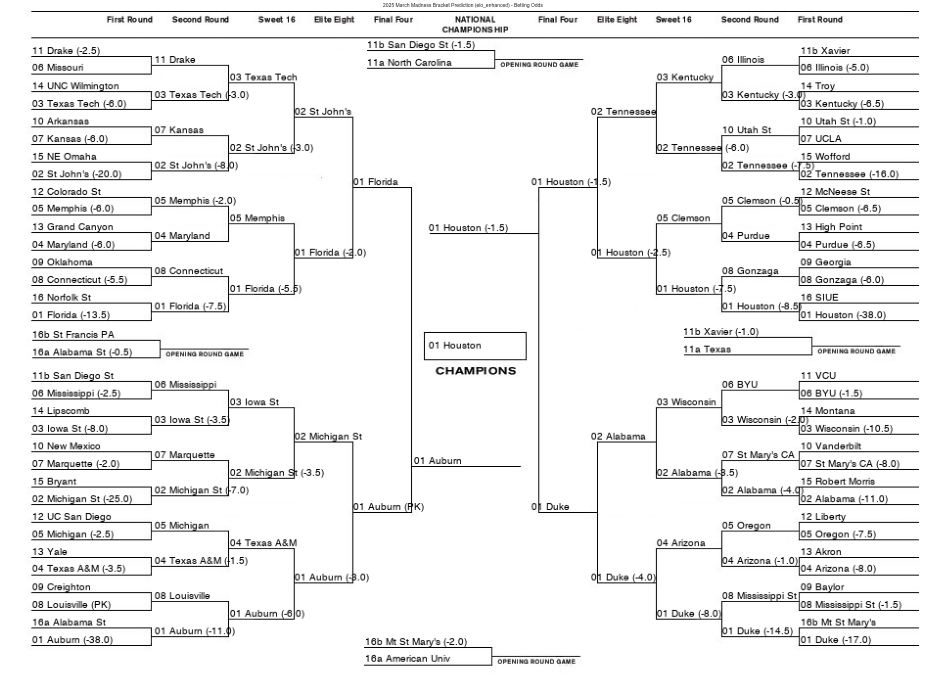

Saved men's bracket visualization to output/2025_mens_bracket.png


In [ ]:
# Visualize Men's Tournament Bracket
try:
    # Generate predictions for actual tournament teams
    men_tourney_predictions = men_predictor.predict_tournament_bracket(method=men_best_method)
    print(f"Generated predictions for {len(men_tourney_predictions)//2} matchups between men's tournament teams")
    
    # Initialize the bracket simulator
    men_simulator = BracketSimulator(men_predictor)
    men_simulator.use_predictor_data()
    
    # Build the bracket structure
    men_bracket_tree, men_seed_slot_map = men_simulator.build_bracket_tree()
    
    # Generate the bracket visualization
    print("Generating men's tournament bracket visualization...")
    men_simulator.visualize_bracket(
        method=men_best_method,
        output_path=f"output/{CURRENT_SEASON}_mens_bracket.png",
        betting_odds=True
    )

    men_simulator.visualize_bracket(
        method=men_best_method,
        output_path=f"output/{CURRENT_SEASON}_mens_bracket_prob.png",
        betting_odds=False
    )
    
    print(f"Saved men's bracket visualization to output/{CURRENT_SEASON}_mens_bracket.png")
except Exception as e:
    print(f"Could not generate men's tournament bracket: {e}")
    print("This functionality will work once the tournament bracket is released.")

Saved bracket to output/2025_mens_bracket_prob.png


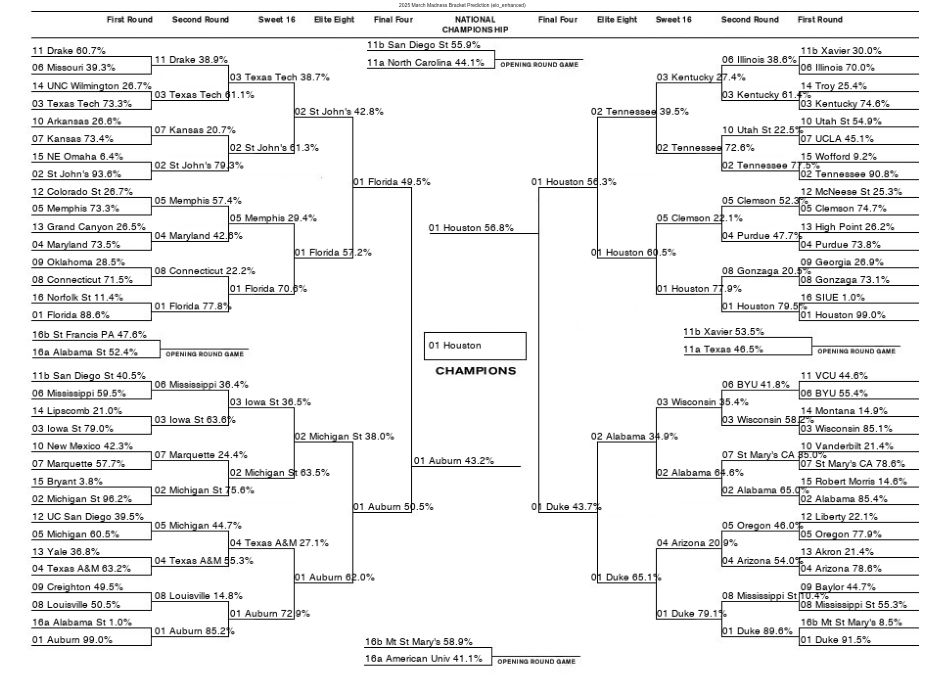

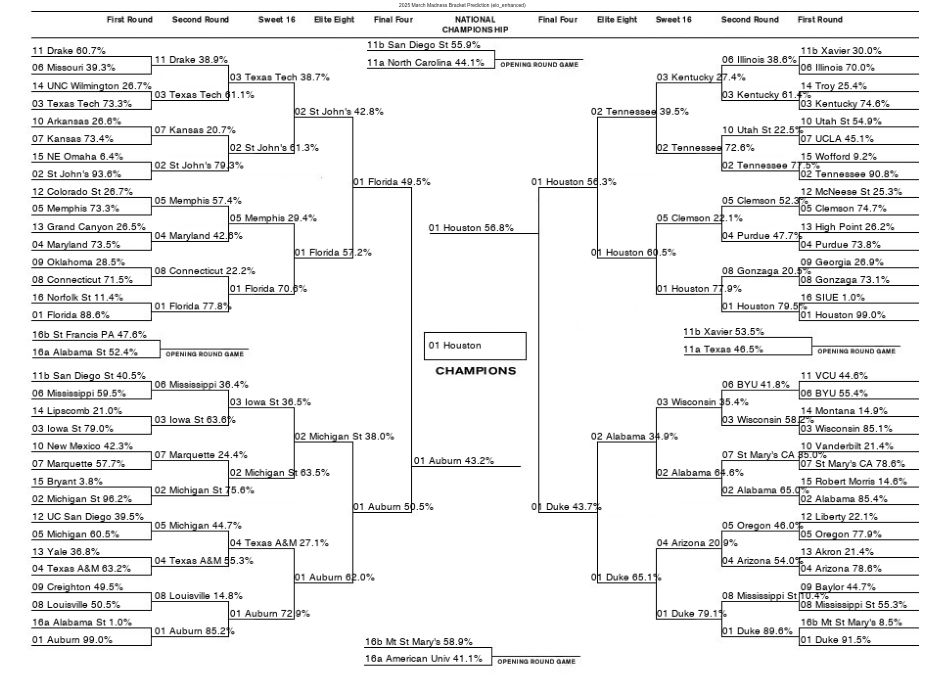

In [19]:
men_simulator.visualize_bracket(
        method=men_best_method,
        output_path=f"output/{CURRENT_SEASON}_mens_bracket_prob.png",
        betting_odds=False
    )

Predicting tournament bracket for 68 teams...
Generating predictions using elo_enhanced method...
new
Generating predictions for 68 tournament teams (2278 matchups)
Processed 1000/2278 matchups (43.9%)
Processed 2000/2278 matchups (87.8%)
Generated predictions for 1139 matchups between women's tournament teams
Index(['Season', 'Slot', 'StrongSeed', 'WeakSeed'], dtype='object')
Generating women's tournament bracket visualization...
Saved bracket to output/2025_womens_bracket.png


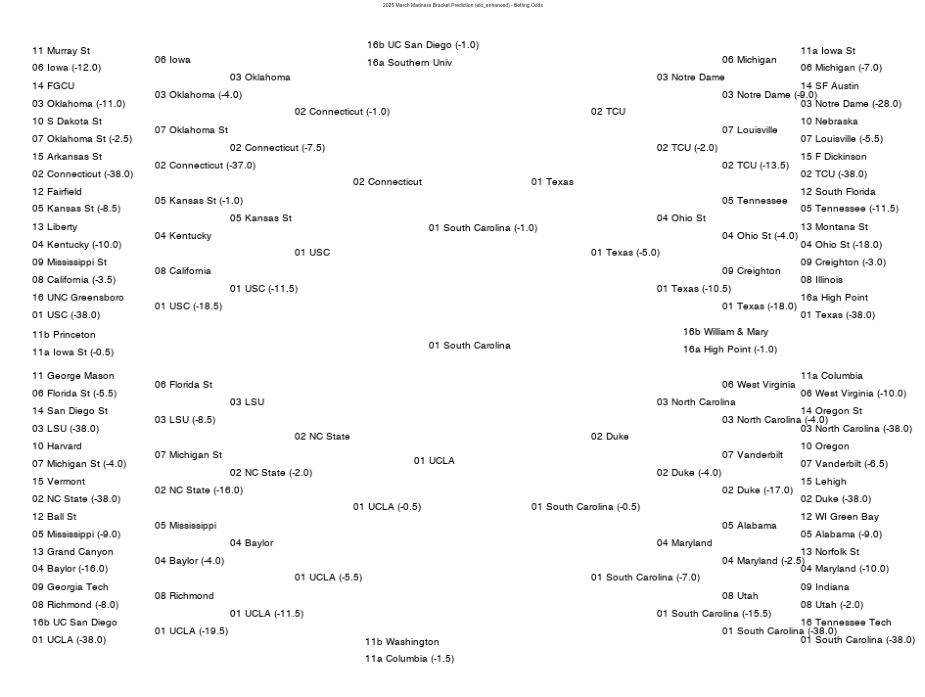

Saved women's bracket visualization to output/2025_womens_bracket.png


In [34]:
# Visualize Women's Tournament Bracket
try:
    # Generate predictions for actual tournament teams
    women_tourney_predictions = women_predictor.predict_tournament_bracket(method=women_best_method)
    print(f"Generated predictions for {len(women_tourney_predictions)//2} matchups between women's tournament teams")
    
    # Initialize the bracket simulator
    women_simulator = BracketSimulator(women_predictor)
    women_simulator.use_predictor_data()
    
    # Build the bracket structure
    women_bracket_tree, women_seed_slot_map = women_simulator.build_bracket_tree()
    
    # Generate the bracket visualization
    print("Generating women's tournament bracket visualization...")
    women_simulator.visualize_bracket(
        method=women_best_method,
        output_path=f"output/{CURRENT_SEASON}_womens_bracket.png",
        betting_odds=True
    )
    
    print(f"Saved women's bracket visualization to output/{CURRENT_SEASON}_womens_bracket.png")
except Exception as e:
    print(f"Could not generate women's tournament bracket: {e}")
    print("This functionality will work once the tournament bracket is released.")

## 8. Explore Specific Team Paths

In [ ]:
# Define a function to explore a specific team's path through the tournament
def explore_team_path(team_name, simulator: BracketSimulator, data_manager: MarchMadnessDataManager, gender="Men's"):
    # Get the team ID from the name
    team_id = None
    teams_df = data_manager.data['teams']
    matching_teams = teams_df[teams_df['TeamName'].str.contains(team_name, case=False)]
    
    if len(matching_teams) == 0:
        print(f"No {gender.lower()} teams found matching '{team_name}'")
        return
    elif len(matching_teams) > 1:
        print(f"Multiple {gender.lower()} teams found matching '{team_name}':")
        for _, team in matching_teams.iterrows():
            print(f"  - {team['TeamName']} (ID: {team['TeamID']})")
        team_id = matching_teams.iloc[0]['TeamID']
        print(f"Using first match: {matching_teams.iloc[0]['TeamName']} (ID: {team_id})")
    else:
        team_id = matching_teams.iloc[0]['TeamID']
    
    try:
        # Get the team's seed
        team_seed = data_manager.seed_lookup.get((CURRENT_SEASON, team_id), "Unknown")
        print(f"\nExploring {gender} tournament path for {team_seed} seed {data_manager.get_team_name(team_id)} (ID: {team_id})")
        
        # Get the team's tournament path
        path = simulator.get_team_path(team_id)
        
        # Create a DataFrame for the path
        path_df = pd.DataFrame([
            {
                "Round": p["round"],
                "Opponent": p["opponent_name"],
                "Opponent Seed": p["opponent_seed"],
                "Win Probability": f"{p['win_probability']:.1%}"
            }
            for p in path
        ])
        
        display(path_df)
        
        # Calculate championship probability
        champ_prob = np.prod([p["win_probability"] for p in path])
        print(f"Championship probability: {champ_prob:.2%}")
        
    except Exception as e:
        print(f"Error getting team path: {e}")
        print("This functionality will work once the tournament bracket is released.")

In [24]:
# Example: Explore path for a men's team (will work after bracket release)
try:
    explore_team_path("Duke", men_simulator, men_data_manager, "Men's")
except Exception as e:
    print(f"Could not explore team path: {e}")
    print("This functionality will work once the tournament bracket is released.")


Exploring Men's tournament path for 1 seed Duke (ID: 1181)


,Round,Opponent,Opponent Seed,Win Probability
0,Play-In,Mt St Mary's,W16b,91.5%
1,First Round,Mississippi St,W08,89.6%
2,Round of 32,Arizona,W04,79.1%
3,Sweet Sixteen,Alabama,W02,65.1%
4,Elite Eight,Houston,X01,43.7%
5,Final Four,Auburn,Y01,56.8%


Championship probability: 10.47%


In [ ]:
# Example: Explore path for a women's team (will work after bracket release)
try:
    explore_team_path("South Carolina", women_simulator, women_data_manager, "Women's")
except Exception as e:
    print(f"Could not explore team path: {e}")
    print("This functionality will work once the tournament bracket is released.")

In [36]:
from bracket_analysis import generate_analysis_from_predictor
# Pass your already-initialized predictor with all data loaded
output_file = generate_analysis_from_predictor(
    predictor=men_predictor,
    method="elo_enhanced",
    output_file="men_analysis.md"
)

Generating predictions using elo_enhanced method...
new
Generating predictions for 68 tournament teams (2278 matchups)
Processed 1000/2278 matchups (43.9%)
Processed 2000/2278 matchups (87.8%)
Analysis written to men_analysis.md


## 9. Summary

### Model Approach
We've implemented an ELO-enhanced ML approach that uses ELO ratings as the foundation and machine learning to predict corrections to those ratings. This hybrid approach leverages the strengths of both methods:

- ELO provides reliable baseline predictions based on historical performance
- ML model learns patterns that ELO misses (like matchup-specific factors)
- System falls back to ELO when ML is uncertain or lacks data

### Files Generated

- `submission_2025.csv`: Combined men's and women's predictions for all possible matchups
- `submission_2025_M.csv`: Men's tournament specific predictions
- `submission_2025_W.csv`: Women's tournament specific predictions
- `output/2025_mens_bracket.png`: Visualized men's tournament bracket with predictions
- `output/2025_womens_bracket.png`: Visualized women's tournament bracket with predictions

### Next Steps

1. Once tournament brackets are released, run the visualization cells again to see predictions for actual tournament teams
2. Use the explore_team_path function to analyze specific teams of interest
3. Submit the combined predictions file to the competition

### Performance Metrics

The backtesting results indicate that the ELO-enhanced approach generally outperforms pure ELO, particularly in terms of log loss which is the competition's scoring metric.